In [2]:
import pandas as pd

df = pd.read_csv("/Users/laasyab/Downloads/superstore.csv")
print(df.shape)
print(df.head())
print(df.info())

(51290, 27)
          Category         City        Country Customer.ID     Customer.Name  \
0  Office Supplies  Los Angeles  United States   LS-172304  Lycoris Saunders   
1  Office Supplies  Los Angeles  United States   MV-174854     Mark Van Huff   
2  Office Supplies  Los Angeles  United States   CS-121304      Chad Sievert   
3  Office Supplies  Los Angeles  United States   CS-121304      Chad Sievert   
4  Office Supplies  Los Angeles  United States   AP-109154    Arthur Prichep   

   Discount Market  记录数               Order.Date        Order.ID  ... Sales  \
0       0.0     US    1  2011-01-07 00:00:00.000  CA-2011-130813  ...    19   
1       0.0     US    1  2011-01-21 00:00:00.000  CA-2011-148614  ...    19   
2       0.0     US    1  2011-08-05 00:00:00.000  CA-2011-118962  ...    21   
3       0.0     US    1  2011-08-05 00:00:00.000  CA-2011-118962  ...   111   
4       0.0     US    1  2011-09-29 00:00:00.000  CA-2011-146969  ...     6   

    Segment                Ship.

In [3]:
df['Order.Date'] = pd.to_datetime(df['Order.Date'])
df['Ship.Date'] = pd.to_datetime(df['Ship.Date'])

In [4]:
df['YearMonth'] = df['Order.Date'].dt.to_period('M')  # for monthly trend
df['Month'] = df['Order.Date'].dt.month
df['Year'] = df['Order.Date'].dt.year
df['ProfitMargin'] = df['Profit'] / df['Sales']

# 4. Aggregate key metrics for dashboard
total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()

sales_by_category = df.groupby('Category')['Sales'].sum().reset_index()
profit_by_region = df.groupby('Region')['Profit'].sum().reset_index()
monthly_sales = df.groupby('YearMonth')['Sales'].sum().reset_index()
monthly_sales['YearMonth'] = monthly_sales['YearMonth'].astype(str)  # convert for plotting

# 5. Optional: top 5 states by sales
top_states = df.groupby('State')['Sales'].sum().sort_values(ascending=False).head(5).reset_index()

print("Data transformation complete ✅")
print(f"Total Sales: ${total_sales:,.2f}, Total Profit: ${total_profit:,.2f}")

Data transformation complete ✅
Total Sales: $12,642,905.00, Total Profit: $1,467,457.29


In [5]:
pip install plotly

Note: you may need to restart the kernel to use updated packages.


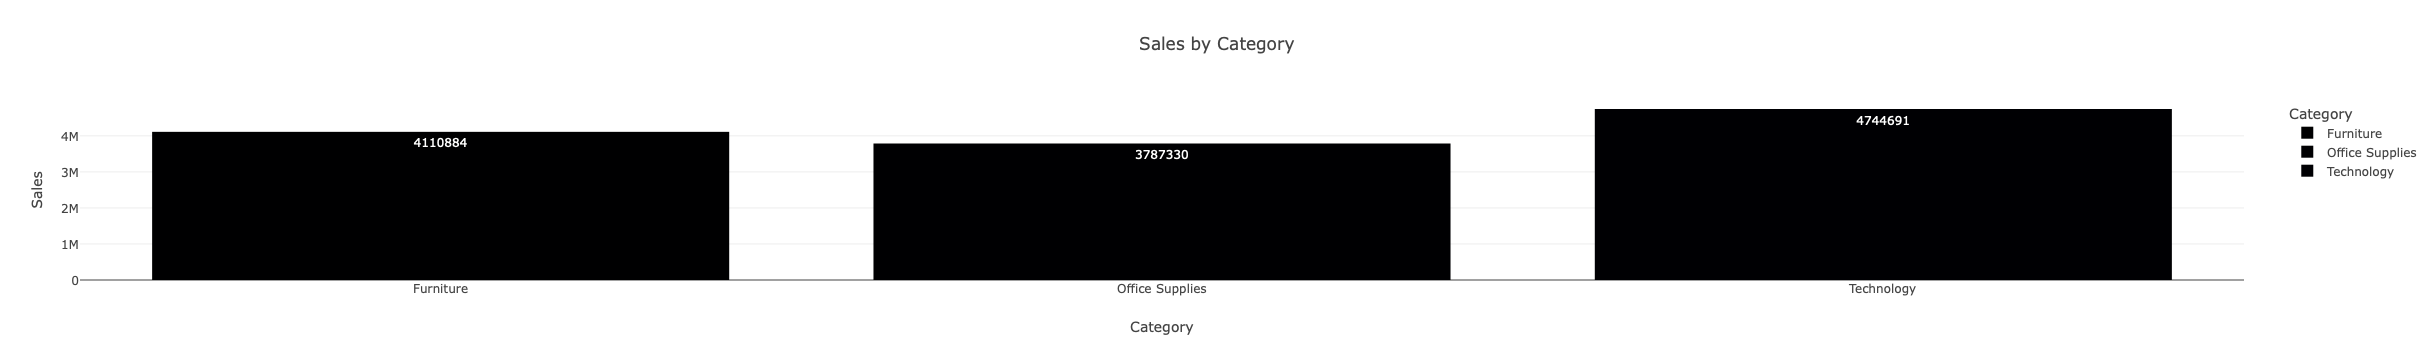

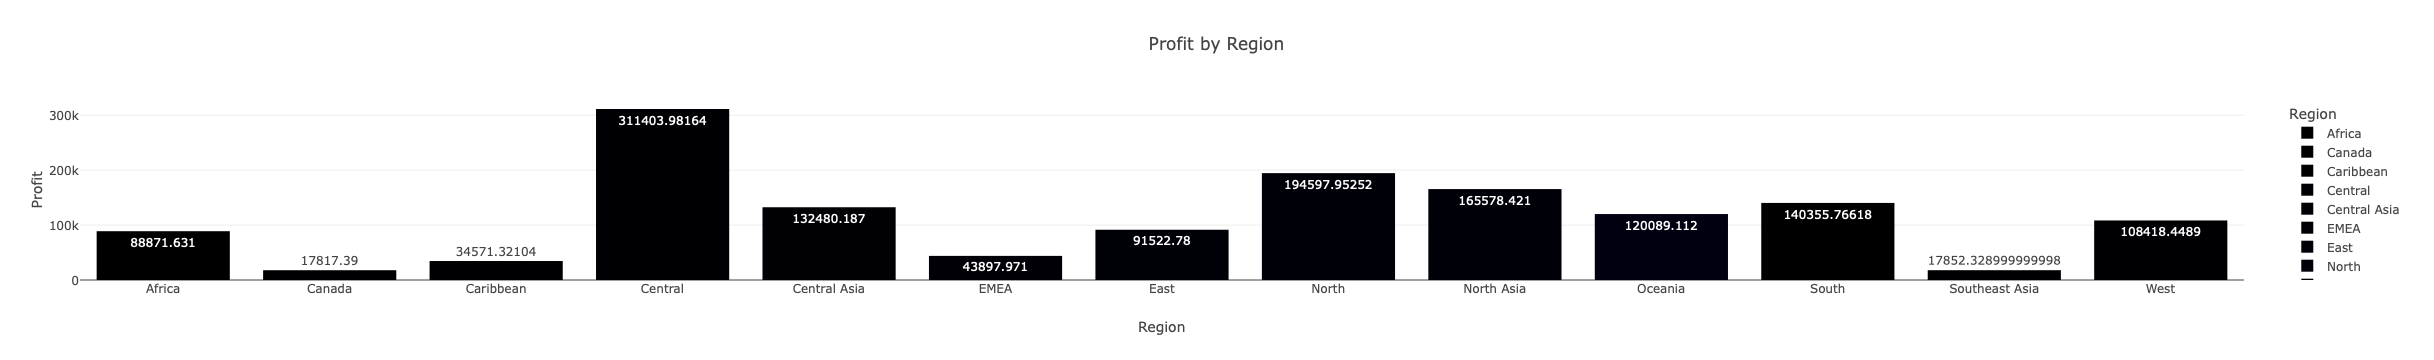

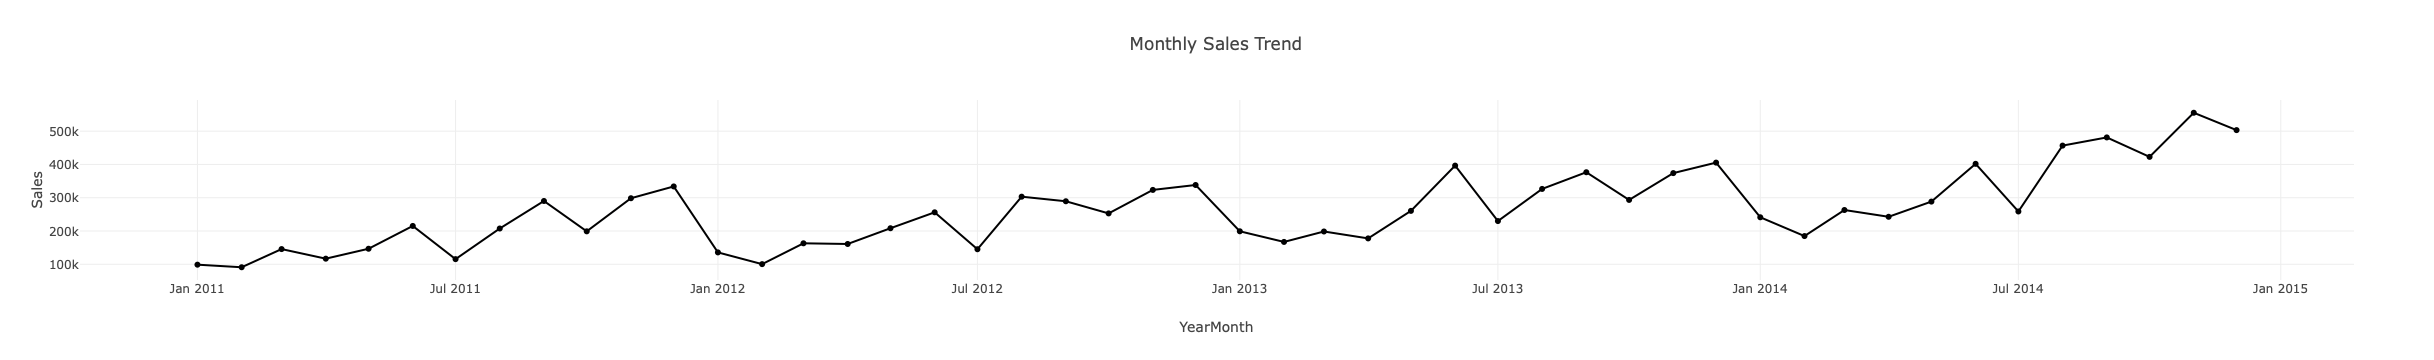

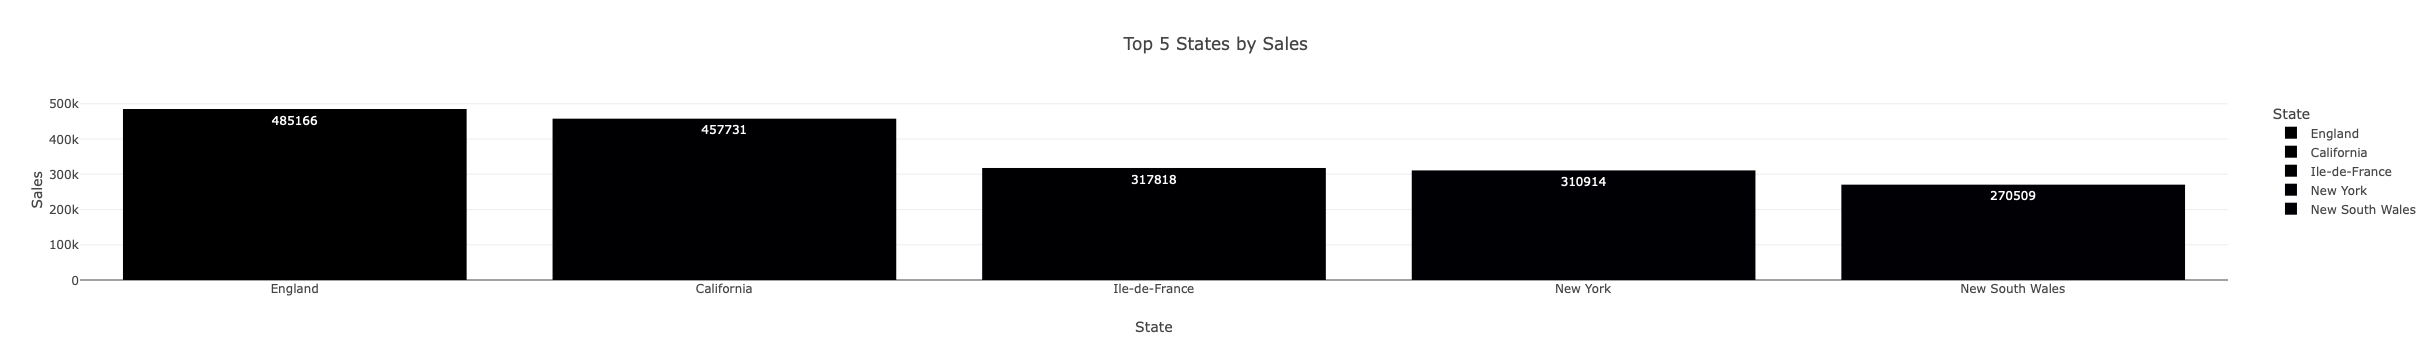

In [6]:
import plotly.express as px

# 1️⃣ Sales by Category
fig_sales_category = px.bar(
    sales_by_category,
    x='Category',
    y='Sales',
    title="Sales by Category",
    text='Sales',
    color='Category'
)
fig_sales_category.show()

# 2️⃣ Profit by Region
fig_profit_region = px.bar(
    profit_by_region,
    x='Region',
    y='Profit',
    title="Profit by Region",
    text='Profit',
    color='Region'
)
fig_profit_region.show()

# 3️⃣ Monthly Sales Trend
fig_monthly_sales = px.line(
    monthly_sales,
    x='YearMonth',
    y='Sales',
    title="Monthly Sales Trend",
    markers=True
)
fig_monthly_sales.show()

# 4️⃣ Top 5 States by Sales
fig_top_states = px.bar(
    top_states,
    x='State',
    y='Sales',
    title="Top 5 States by Sales",
    text='Sales',
    color='State'
)
fig_top_states.show()

In [7]:
from sklearn.linear_model import LinearRegression
import numpy as np

# Prepare data for modeling
monthly_sales['Month_Num'] = range(len(monthly_sales))  # numeric month for regression
X = monthly_sales[['Month_Num']]
y = monthly_sales['Sales']

# Train linear regression
model = LinearRegression()
model.fit(X, y)

# Predict next month
next_month = np.array([[len(monthly_sales)]])
predicted_sales = model.predict(next_month)[0]
print(f"Predicted Sales for next month: ${predicted_sales:,.2f}")
# Prepare next month data with proper column name
next_month = pd.DataFrame({'Month_Num': [len(monthly_sales)]})


Predicted Sales for next month: $407,485.56


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning:

X does not have valid feature names, but LinearRegression was fitted with feature names



In [9]:
import streamlit as st
import plotly.express as px

st.title("Superstore Sales Dashboard")

# KPI metrics
st.metric("Total Sales", f"${total_sales:,.2f}")
st.metric("Total Profit", f"${total_profit:,.2f}")
st.metric("Predicted Next Month Sales", f"${predicted_sales:,.2f}")

# Visualizations
st.subheader("Sales by Category")
st.plotly_chart(fig_sales_category)

st.subheader("Profit by Region")
st.plotly_chart(fig_profit_region)

st.subheader("Monthly Sales Trend")
st.plotly_chart(fig_monthly_sales)

st.subheader("Top 5 States by Sales")
st.plotly_chart(fig_top_states)

2026-04-07 19:26:49.062 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-07 19:26:49.063 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-07 19:26:49.063 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-07 19:26:49.064 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-07 19:26:49.064 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-07 19:26:49.065 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-07 19:26:49.065 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-07 19:26:49.065 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

DeltaGenerator()